In [1]:
import mne
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback

from scipy.signal import butter, filtfilt, resample
from sklearn.metrics import classification_report, confusion_matrix,f1_score, accuracy_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

2026-03-13 16:16:07.833890: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773418568.042473      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773418568.095961      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773418568.527208      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773418568.527247      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773418568.527250      55 computation_placer.cc:177] computation placer alr

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU enabled")
    except RuntimeError as e:
        print(e)

GPU enabled


In [3]:
# ── Verify versions ────────────────────────────────────────────────────────────
print(f'TensorFlow : {tf.__version__}')
print(f'MNE        : {mne.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.19.0
MNE        : 1.11.0
NumPy      : 2.0.2
GPU available: True


In [4]:
# 1. Define the specific path to a file
# Based on your image: /kaggle/input/bci-4-2a/BCICIV_2a/A01T.gdf
file_path = '/kaggle/input/datasets/mok18976/bci-4-2a/BCICIV_2a/A01T.gdf'

# 2. Load the raw GDF file
# eog=[22, 23, 24] identifies the Electrooculogram channels (eye movement noise)
raw = mne.io.read_raw_gdf(file_path, eog=[22, 23, 24], preload=True)

# 3. Print basic dataset info
print("--- BASIC INFO ---")
print(raw.info)

# 4. See the channel names
print("\n--- CHANNEL NAMES ---")
print(raw.ch_names)

# 5. Look at the events/markers (visual cues, start of trial, etc.)
events, event_id = mne.events_from_annotations(raw)
print("\n--- EVENT MAPPING ---")
print(event_id)

# 6. Summary of data shape
data, times = raw[:]
print(f"\nData Shape: {data.shape} (Channels x Time points)")

Extracting GDF parameters from /kaggle/input/datasets/mok18976/bci-4-2a/BCICIV_2a/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...
--- BASIC INFO ---
<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 22 EEG, 3 EOG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>

--- CHANNEL NAMES ---
['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-1

In [5]:
#--------------------------------
# Configuration & Data Loading
#--------------------------------

DATA_PATH    = '/kaggle/input/datasets/mok18976/bci-4-2a/BCICIV_2a' 
N_SUBJECTS   = 9
SFREQ_ORIG   = 250     # original sampling rate Hz
SFREQ_NEW    = 128     # target sampling rate Hz 
#we can downsample the data
#Then according to the niquist the maximum frequency that can recovered is 64Hz and it is in EEG frequency range.
TMIN         = 0.5     # epoch start seconds post cue 
TMAX         = 2.5     # epoch end seconds post cue 
N_CHANNELS   = 22      # EEG channels in BCI Comp IV 2a
N_CLASSES    = 4       # Left, Right, Feet, Tongue
N_EPOCHS_FIT = 200     # training epochs 
BATCH_SIZE   = 64
F1, D, F2    = 8, 2, 16          # EEGNet-8,2 configuration
KERN_LENGTH  = 32                 # paper uses 32 for SMR 
DROPOUT      = 0.5               # within-subject dropout

CLASS_NAMES  = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
COLORS       = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

# Event IDs in BCI Comp IV 2a training GDF files
EVENT_ID = {'769': 769, '770': 770, '771': 771, '772': 772}

print('Ok -> Configuration set')
print(f'   Data path     : {DATA_PATH}')
print(f'   Subjects      : {N_SUBJECTS}')
print(f'   Sampling rate : {SFREQ_ORIG}Hz → {SFREQ_NEW}Hz')
print(f'   Epoch window  : [{TMIN}, {TMAX}]s')
print(f'   EEGNet config : F1={F1}, D={D}, F2={F2}')

Ok -> Configuration set
   Data path     : /kaggle/input/datasets/mok18976/bci-4-2a/BCICIV_2a
   Subjects      : 9
   Sampling rate : 250Hz → 128Hz
   Epoch window  : [0.5, 2.5]s
   EEGNet config : F1=8, D=2, F2=16


In [6]:
def load_subject_training(data_path, subject_id):
    # Build file path
    fname = os.path.join(data_path, f'A0{subject_id}T.gdf')
    
    if not os.path.exists(fname):
        raise FileNotFoundError(f"File not found: {fname}")

    # 1. Load raw GDF
    raw = mne.io.read_raw_gdf(fname, preload=True, verbose=False)
    
    # 2. Keep only first 22 EEG channels
    raw.pick_channels(raw.ch_names[:22])
    
    # 3. Extract events from annotations
    # GDF files often store events as strings like '769'
    events, event_dict = mne.events_from_annotations(raw, verbose=False)
    
    # 4. Map string annotations to their numeric motor imagery codes
    # We look for descriptions that represent 769, 770, 771, 772
    valid_descriptions = ['769', '770', '771', '772']
    
    # Create a mapping of { 'Description': internal_ID }
    # Only includes descriptions actually found in this specific file
    found_event_id = {d: event_dict[d] for d in valid_descriptions if d in event_dict}
    
    # 5. Filter the events array to only keep these specific IDs
    mask = np.isin(events[:, 2], list(found_event_id.values()))
    filtered_events = events[mask]
    
    # 6. Safety check to prevent the "max() iterable argument is empty" error
    if len(filtered_events) == 0:
        print(f"\n Warning: No events found for Subject {subject_id}")
        print(f"   Available in file: {list(event_dict.keys())}")
        return None, None

    # 7. Epoch the data: [0.5, 2.5]s post-cue
    epochs = mne.Epochs(
        raw, 
        filtered_events,
        event_id = found_event_id,
        tmin     = TMIN,
        tmax     = TMAX,
        baseline = None,
        preload  = True,
        verbose  = False
    )
    
    X = epochs.get_data() # (trials, 22, timepoints)
    
    # 8. Map internal MNE IDs back to 0-3 labels for the model
    # Create a reverse lookup: internal_ID -> original_7xx_code
    id_to_code = {v: int(k) for k, v in found_event_id.items()}
    code_to_idx = {769: 0, 770: 1, 771: 2, 772: 3}
    
    y = np.array([code_to_idx[id_to_code[e]] for e in epochs.events[:, 2]])
    
    return X, y

In [7]:
#-----------------------------------
# Load all 9 subjects 
#-----------------------------------

print('Loading all subjects...\n')
all_X_raw, all_y_raw = [], []

for subj in range(1, N_SUBJECTS + 1):
    print(f'  Subject {subj}/{N_SUBJECTS} ... ', end='')
    X, y = load_subject_training(DATA_PATH, subj)
    all_X_raw.append(X)
    all_y_raw.append(y)
    counts = [np.sum(y == i) for i in range(N_CLASSES)]
    print(f'Shape: {X.shape} | Classes: {counts}')

print(f'\n All subjects loaded!')
print(f'   Trials per subject : ~{all_X_raw[0].shape[0]}')
print(f'   Channels           : {all_X_raw[0].shape[1]}')
print(f'   Raw timepoints     : {all_X_raw[0].shape[2]} '
      f'(at {SFREQ_ORIG}Hz)')

Loading all subjects...

  Subject 1/9 ... NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Shape: (288, 22, 501) | Classes: [np.int64(72), np.int64(72), np.int64(72), np.int64(72)]
  Subject 2/9 ... NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Shape: (288, 22, 501) | Classes: [np.int64(72), np.int64(72), np.int64(72), np.int64(72)]
  Subject 3/9 ... NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Shape: (288, 22, 501) | Classes: [np.int64(72), np.int64(72), np.int64(72), np.int64(72)]
  Subject 4/9 ... NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Shape: (288, 22, 501) | Classes: [np.int64(72), np.int64(72), np.int64(72), np.int64(72)]
  Subject 5/9 ... NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Shape: (288, 22, 501) | Classes: [np.int64(72), np.int64(72), np.int64(72), np.int64(72)]
  Subject 6/9 ... NOTE: pick_channe

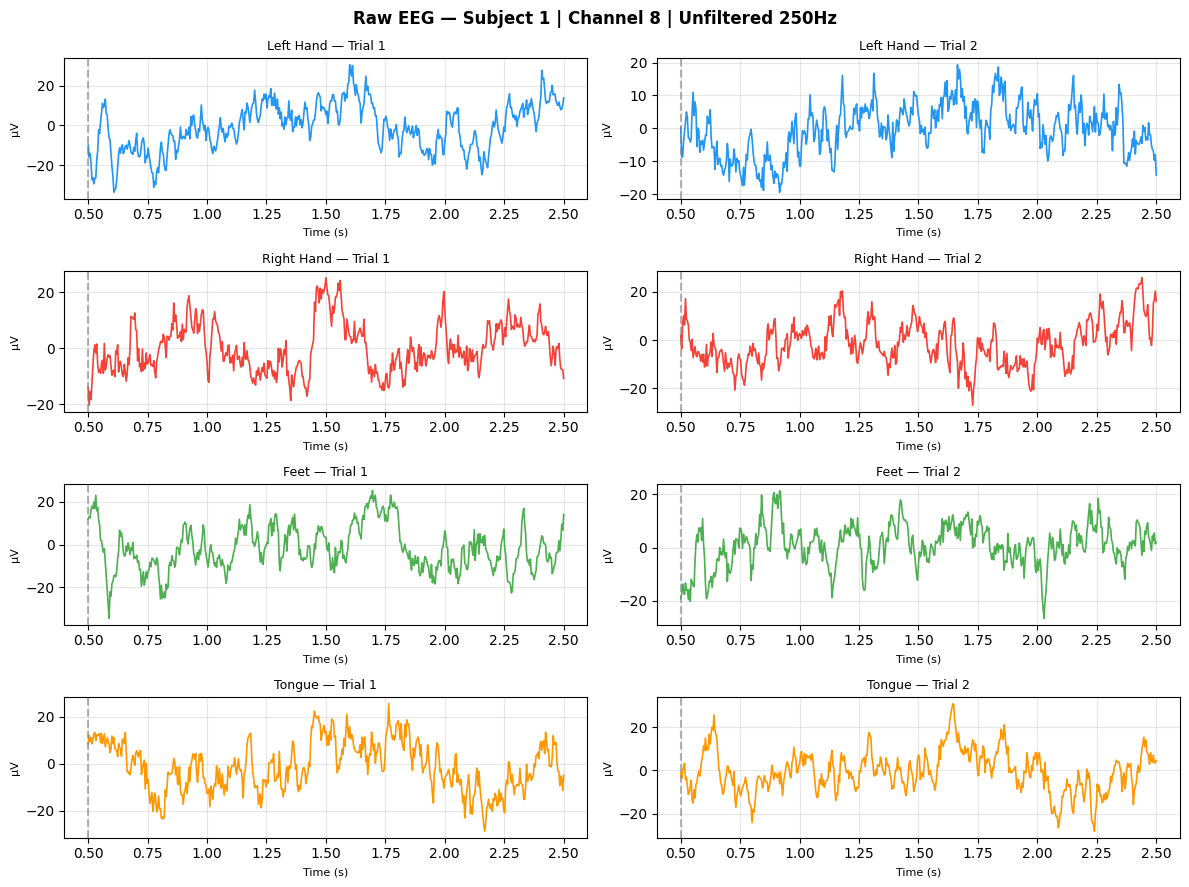

Raw EEG plot saved.


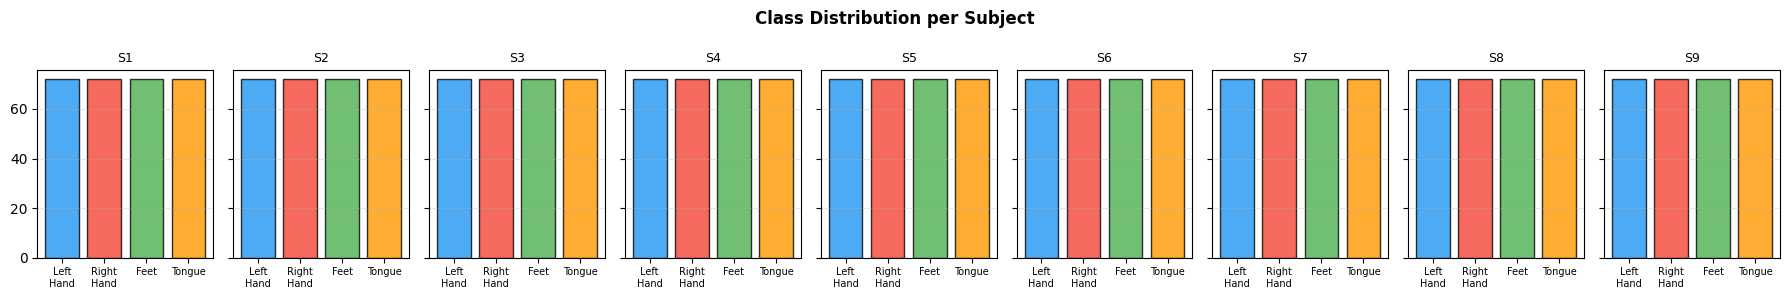

Class distribution plot saved.


In [8]:
#-------------------------
# Visualize Data
#-------------------------
# Cell 4 — Raw EEG visualization

def plot_raw_eeg(X_raw, y_raw, subject_id=0,n_trials_per_class=2, channel_idx=7):
    
    time_raw = np.linspace(TMIN, TMAX, X_raw.shape[2])

    fig, axes = plt.subplots(N_CLASSES, n_trials_per_class,figsize=(12, 9), sharey=False)
    fig.suptitle(
        f'Raw EEG — Subject {subject_id+1} | '
        f'Channel {channel_idx+1} | Unfiltered 250Hz',
        fontsize=12, fontweight='bold'
    )

    for cls_idx in range(N_CLASSES):
        trial_idxs = np.where(y_raw == cls_idx)[0][:n_trials_per_class]
        for t, t_idx in enumerate(trial_idxs):
            ax = axes[cls_idx, t]
            sig = X_raw[t_idx, channel_idx, :] * 1e6  # to µV
            ax.plot(time_raw, sig,
                    color=COLORS[cls_idx], linewidth=1.2)
            ax.axvline(x=TMIN, color='gray',
                       linestyle='--', alpha=0.6)
            ax.set_title(
                f'{CLASS_NAMES[cls_idx]} — Trial {t+1}',
                fontsize=9
            )
            ax.set_xlabel('Time (s)', fontsize=8)
            ax.set_ylabel('µV', fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('raw_eeg.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Raw EEG plot saved.')


def plot_class_distribution(all_y):
    """Bar chart of class distribution across all subjects."""
    fig, axes = plt.subplots(
        1, N_SUBJECTS, figsize=(18, 3), sharey=True
    )
    fig.suptitle('Class Distribution per Subject',
                 fontsize=12, fontweight='bold')

    for subj, (ax, y) in enumerate(zip(axes, all_y)):
        counts = [np.sum(y == i) for i in range(N_CLASSES)]
        ax.bar(CLASS_NAMES, counts,
               color=COLORS, edgecolor='black', alpha=0.8)
        ax.set_title(f'S{subj+1}', fontsize=9)
        ax.set_xticklabels(
            [c.replace(' ', '\n') for c in CLASS_NAMES],
            fontsize=7
        )
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Class distribution plot saved.')


plot_raw_eeg(all_X_raw[0], all_y_raw[0], subject_id=0)
plot_class_distribution(all_y_raw)

In [9]:
# Cell 5 — Preprocessing

def bandpass_filter(data, lowcut=4.0, highcut=40.0,fs=250.0, order=5):
    nyq     = fs / 2.0
    b, a    = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    out     = np.zeros_like(data)
    for i in range(data.shape[0]):
        for ch in range(data.shape[1]):
            out[i, ch, :] = filtfilt(b, a, data[i, ch, :])
    return out


def downsample_trials(data, orig_fs=250, target_fs=128):
    n_new = int(data.shape[2] * target_fs / orig_fs)
    out   = np.zeros((data.shape[0], data.shape[1], n_new),dtype=np.float32)
    for i in range(data.shape[0]):
        for ch in range(data.shape[1]):
            out[i, ch, :] = resample(data[i, ch, :], n_new)
    return out


def preprocess_subject(X, y):
    X_filt = bandpass_filter(X, lowcut=4.0, highcut=40.0, fs=SFREQ_ORIG)
    X_down = downsample_trials(X_filt, SFREQ_ORIG, SFREQ_NEW)

    # Z-score normalize per trial per channel
    mean = X_down.mean(axis=2, keepdims=True)
    std  = X_down.std(axis=2,  keepdims=True) + 1e-8
    X_norm = (X_down - mean) / std

    return X_norm.astype(np.float32), y.astype(np.int32)



In [10]:
#-----------------------------
# Preprocess all subjects
#-----------------------------

print('Preprocessing all subjects...')
print('Pipeline: Bandpass 4-40Hz → Downsample 250→128Hz\n')

all_X_proc, all_y_proc = [], []

for subj in range(N_SUBJECTS):
    print(f'  Subject {subj+1}/{N_SUBJECTS} ... ', end='')
    t0 = time.time()
    Xp, yp = preprocess_subject(all_X_raw[subj], all_y_raw[subj])
    all_X_proc.append(Xp)
    all_y_proc.append(yp)
    print(f'Shape: {Xp.shape} | {time.time()-t0:.1f}s')

n_tp = all_X_proc[0].shape[2]
print(f'\n Preprocessing complete!')
print(f'   Timepoints after downsample : {n_tp} '
      f'(2s × 128Hz = {SFREQ_NEW * int(TMAX - TMIN)} expected)')

Preprocessing all subjects...
Pipeline: Bandpass 4-40Hz → Downsample 250→128Hz

  Subject 1/9 ... Shape: (288, 22, 256) | 1.3s
  Subject 2/9 ... Shape: (288, 22, 256) | 1.3s
  Subject 3/9 ... Shape: (288, 22, 256) | 1.3s
  Subject 4/9 ... Shape: (288, 22, 256) | 1.3s
  Subject 5/9 ... Shape: (288, 22, 256) | 1.3s
  Subject 6/9 ... Shape: (288, 22, 256) | 1.3s
  Subject 7/9 ... Shape: (288, 22, 256) | 1.3s
  Subject 8/9 ... Shape: (288, 22, 256) | 1.3s
  Subject 9/9 ... Shape: (288, 22, 256) | 1.3s

 Preprocessing complete!
   Timepoints after downsample : 256 (2s × 128Hz = 256 expected)


In [11]:
#-----------------------------
#Data Split Summary
#-----------------------------
#Split summary (8-fold within-subject)

def print_split_summary_8fold(all_X, all_y):
    n_tp = all_X[0].shape[2]

    print('=' * 72)
    print(f'{"DATASET SPLIT SUMMARY (Within-Subject 8-Fold CV)":^72}')
    print('=' * 72)
    print(f'  Subjects            : {N_SUBJECTS}')
    print(f'  EEG Channels        : {N_CHANNELS}')
    print(f'  Sampling Rate       : {SFREQ_NEW} Hz')
    print(f'  Epoch Window        : [{TMIN}, {TMAX}]s post cue')
    print(f'  Timepoints/Trial    : {n_tp}')
    print(f'  Classes             : {CLASS_NAMES}')
    print(f'  Folds               : 8 (blockwise)')
    print(f'  Fold split          : 6 train / 1 val / 1 test')
    print(f'  Train/Val/Test      : 75% / 12.5% / 12.5%')
    print(f'  Input Tensor Shape  : (1, {N_CHANNELS}, {n_tp})')
    print()

    # ── Per-subject breakdown ──────────────────────────────────────────────────
    header = (f'{"Subj":>5} | {"Total":>6} | '
              + ' | '.join(f'{c[:5]:>6}' for c in CLASS_NAMES)
              + f' | {"~Train":>7} | {"~Val":>7} | {"~Test":>7}'
              + f' | {"Blk Sz":>7}')
    print(header)
    print('-' * 72)

    for subj in range(N_SUBJECTS):
        y          = all_y[subj]
        n          = len(y)
        cls_counts = [np.sum(y == i) for i in range(N_CLASSES)]

        block_size = n // 8
        n_test     = block_size                    # 1 block  = 12.5%
        n_val      = block_size                    # 1 block  = 12.5%
        n_train    = n - n_test - n_val            # 6 blocks = 75%

        row = (f'{subj+1:>5} | {n:>6} | '
               + ' | '.join(f'{c:>6}' for c in cls_counts)
               + f' | {n_train:>7}'
               + f' | {n_val:>7}'
               + f' | {n_test:>7}'
               + f' | {block_size:>7}')
        print(row)

    # ── Totals row ─────────────────────────────────────────────────────────────
    all_y_concat = np.concatenate(all_y)
    total        = len(all_y_concat)
    totals       = [np.sum(all_y_concat == i) for i in range(N_CLASSES)]

    avg_block    = total // (N_SUBJECTS * 8)
    n_test_tot   = avg_block * N_SUBJECTS
    n_val_tot    = avg_block * N_SUBJECTS
    n_train_tot  = total - n_test_tot - n_val_tot

    print('-' * 72)
    row = (f'{"ALL":>5} | {total:>6} | '
           + ' | '.join(f'{c:>6}' for c in totals)
           + f' | {n_train_tot:>7}'
           + f' | {n_val_tot:>7}'
           + f' | {n_test_tot:>7}'
           + f' | {"":>7}')
    print(row)
    print('=' * 72)

    # ── Percentage summary ─────────────────────────────────────────────────────
    n_sample   = len(all_y[0])
    block_sz   = n_sample // 8
    n_tr       = block_sz * 6
    n_v        = block_sz
    n_te       = block_sz

    print()
    print(f'  Per-fold trial breakdown (based on Subject 1):')
    print(f'  {"Set":<10} {"Blocks Used":<18} '
          f'{"Trials":>8} {"Percent":>9}')
    print(f'  {"-"*48}')
    print(f'  {"Train":<10} {"6 of 8 blocks":<18} '
          f'{n_tr:>8} {n_tr/n_sample:>8.1%}')
    print(f'  {"Val":<10} {"1 of 8 blocks":<18} '
          f'{n_v:>8} {n_v/n_sample:>8.1%}')
    print(f'  {"Test":<10} {"1 of 8 blocks":<18} '
          f'{n_te:>8} {n_te/n_sample:>8.1%}')
    print(f'  {"-"*48}')
    print(f'  {"Total":<10} {"8 blocks":<18} '
          f'{n_sample:>8} {"100.0%":>9}')

    # ── Comparison vs 4-fold ───────────────────────────────────────────────────
    print()
    print(f'  Comparison vs Paper 4-fold:')
    print(f'  {"Metric":<22} {"4-Fold (paper)":>16} '
          f'{"8-Fold (current)":>18}')
    print(f'  {"-"*58}')

    n4_train = n_sample // 2
    n4_val   = n_sample // 4
    n4_test  = n_sample // 4

    print(f'  {"Train trials":<22} {n4_train:>16} {n_tr:>18}')
    print(f'  {"Val trials":<22} {n4_val:>16}  {n_v:>17}')
    print(f'  {"Test trials":<22} {n4_test:>16}  {n_te:>17}')
    print(f'  {"Train %":<22} {"50.0%":>16} {"75.0%":>18}')
    print(f'  {"Val %":<22} {"25.0%":>16} {"12.5%":>18}')
    print(f'  {"Test %":<22} {"25.0%":>16} {"12.5%":>18}')
    print(f'  {"Number of folds":<22} {"4":>16} {"8":>18}')
    print(f'  {"Extra train data":<22} {"baseline":>16} '
          f'{((n_tr/n4_train)-1)*100:>17.1f}%')
    print()
    print(f'   8-fold gives {n_tr - n4_train} more training trials'
          f' per fold (+{((n_tr/n4_train)-1)*100:.0f}%)')
    print(f'    8-fold test set is smaller '
          f'({n_te} vs {n4_test} trials) — noisier estimate')
    print('=' * 72)


# Run the summary
print_split_summary_8fold(all_X_proc, all_y_proc)

            DATASET SPLIT SUMMARY (Within-Subject 8-Fold CV)            
  Subjects            : 9
  EEG Channels        : 22
  Sampling Rate       : 128 Hz
  Epoch Window        : [0.5, 2.5]s post cue
  Timepoints/Trial    : 256
  Classes             : ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
  Folds               : 8 (blockwise)
  Fold split          : 6 train / 1 val / 1 test
  Train/Val/Test      : 75% / 12.5% / 12.5%
  Input Tensor Shape  : (1, 22, 256)

 Subj |  Total |  Left  |  Right |   Feet |  Tongu |  ~Train |    ~Val |   ~Test |  Blk Sz
------------------------------------------------------------------------
    1 |    288 |     72 |     72 |     72 |     72 |     216 |      36 |      36 |      36
    2 |    288 |     72 |     72 |     72 |     72 |     216 |      36 |      36 |      36
    3 |    288 |     72 |     72 |     72 |     72 |     216 |      36 |      36 |      36
    4 |    288 |     72 |     72 |     72 |     72 |     216 |      36 |      36 |      36
   

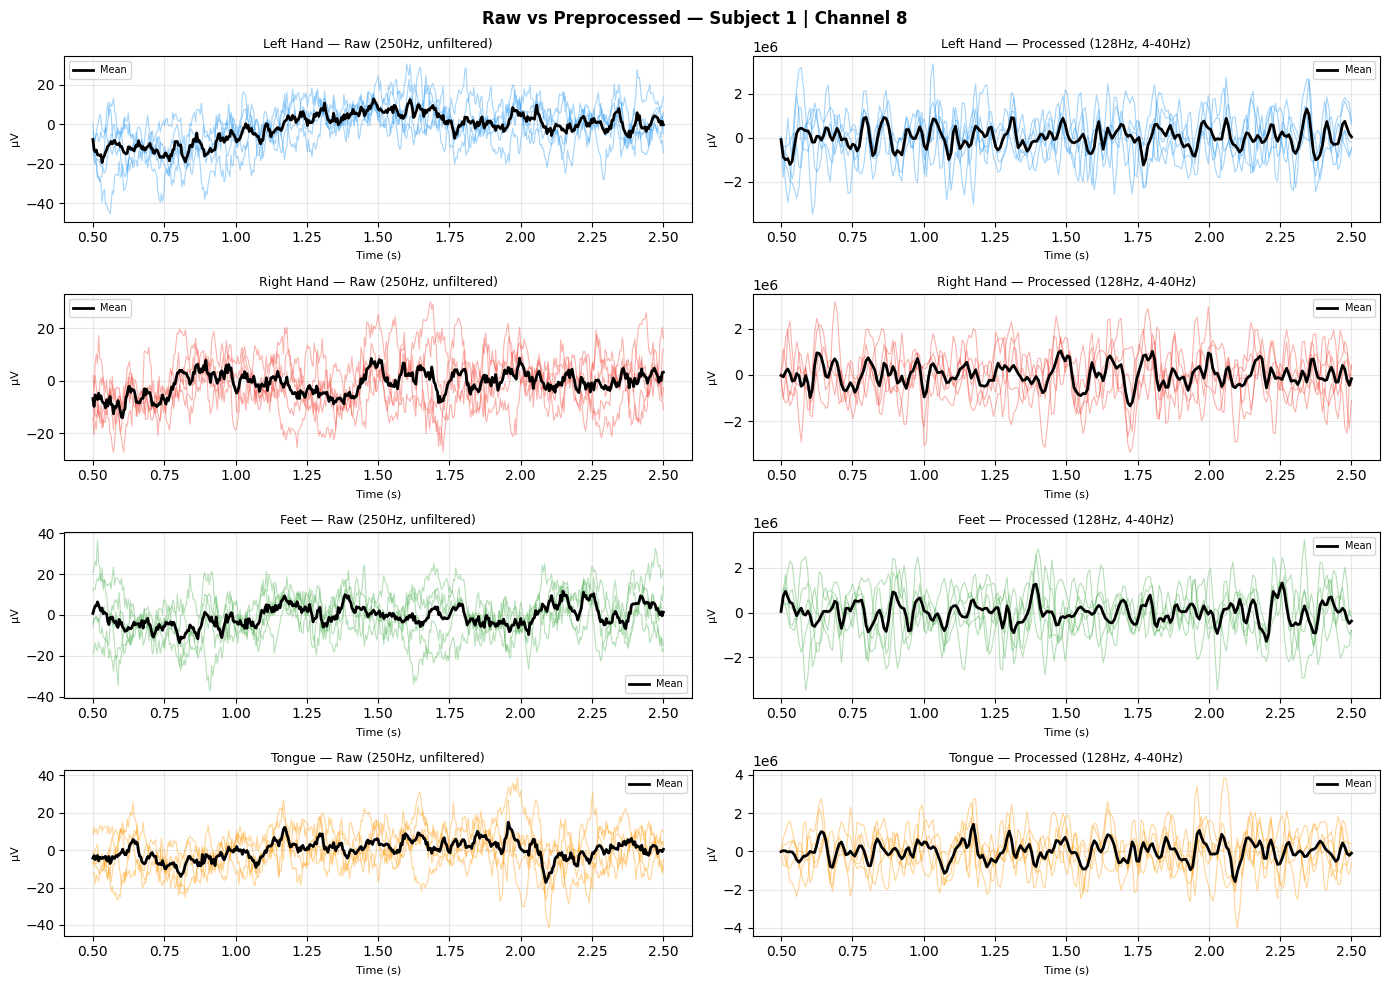

 Preprocessed comparison saved.


In [12]:
#------------------------------
# Visualize Preprocessed Data
#------------------------------
def plot_preprocessed_comparison(X_raw, X_proc, y,
                                  subject_id=0, channel_idx=7):
    time_raw  = np.linspace(TMIN, TMAX, X_raw.shape[2])
    time_proc = np.linspace(TMIN, TMAX, X_proc.shape[2])

    fig, axes = plt.subplots(N_CLASSES, 2, figsize=(14, 10))
    fig.suptitle(
        f'Raw vs Preprocessed — Subject {subject_id+1} '
        f'| Channel {channel_idx+1}',
        fontsize=12, fontweight='bold'
    )

    for cls_idx in range(N_CLASSES):
        trial_idxs = np.where(y == cls_idx)[0][:5]

        ax_r = axes[cls_idx, 0]
        ax_p = axes[cls_idx, 1]

        for t_idx in trial_idxs:
            ax_r.plot(time_raw,
                      X_raw[t_idx, channel_idx, :] * 1e6,
                      alpha=0.4, color=COLORS[cls_idx],
                      linewidth=0.8)
            ax_p.plot(time_proc,
                      X_proc[t_idx, channel_idx, :] * 1e6,
                      alpha=0.4, color=COLORS[cls_idx],
                      linewidth=0.8)

        # Mean line
        mean_r = X_raw[trial_idxs, channel_idx, :].mean(0) * 1e6
        mean_p = X_proc[trial_idxs, channel_idx, :].mean(0) * 1e6
        ax_r.plot(time_raw,  mean_r, 'k-', linewidth=2, label='Mean')
        ax_p.plot(time_proc, mean_p, 'k-', linewidth=2, label='Mean')

        ax_r.set_title(
            f'{CLASS_NAMES[cls_idx]} — Raw (250Hz, unfiltered)',
            fontsize=9
        )
        ax_p.set_title(
            f'{CLASS_NAMES[cls_idx]} — Processed (128Hz, 4-40Hz)',
            fontsize=9
        )
        for ax in [ax_r, ax_p]:
            ax.set_ylabel('µV', fontsize=8)
            ax.set_xlabel('Time (s)', fontsize=8)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('preprocessed_comparison.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(' Preprocessed comparison saved.')


plot_preprocessed_comparison(
    all_X_raw[0], all_X_proc[0],
    all_y_proc[0], subject_id=0
)

In [13]:
#----------------------
# Build EEGNet Architecture
#----------------------
def build_eegnet(n_channels=22, n_timepoints=256,n_classes=4, F1=8, D=2, F2=16,dropout_rate=0.5, kern_length=32):
    
    inputs = layers.Input(shape=(1, n_channels, n_timepoints),name='EEG_Input')

    # Reshape to channels_last format for Keras 3
    x = layers.Permute((2, 3, 1), name='Permute')(inputs)
    
    # Temporal conv — learns bandpass frequency filters
    x = layers.Conv2D(
        filters     = F1,
        kernel_size = (1, kern_length),
        padding     = 'same',
        use_bias    = False,
        name        = 'B1_TemporalConv'
    )(x)
    x = layers.BatchNormalization(name='B1_BN1')(x)

    # Depthwise conv — learns frequency-specific spatial filters
    x = layers.DepthwiseConv2D(
        kernel_size          = (n_channels, 1),
        depth_multiplier     = D,
        padding              = 'valid',
        use_bias             = False,
        data_format          = 'channels_last',
        depthwise_constraint = max_norm(1.0),
        name                 = 'B1_DepthwiseConv'
    )(x)

    
    x = layers.BatchNormalization(name='B1_BN2')(x)
    x = layers.Activation('elu', name='B1_ELU')(x)
    x = layers.AveragePooling2D(pool_size=(1, 4), name='B1_AvgPool')(x)
    x = layers.Dropout(dropout_rate, name='B1_Dropout')(x)

    # Separable conv — temporal summary + feature mixing
    x = layers.SeparableConv2D(
        filters     = F2,
        kernel_size = (1, 16),
        padding     = 'same',
        use_bias    = False,
        data_format = 'channels_last',
        name        = 'B2_SeparableConv'
    )(x)
    
    x = layers.BatchNormalization(name='B2_BN')(x)
    x = layers.Activation('elu', name='B2_ELU')(x)
    x = layers.AveragePooling2D(pool_size=(1, 8), name='B2_AvgPool')(x)
    x = layers.Dropout(dropout_rate, name='B2_Dropout')(x)

    # ── CLASSIFIER ────────────────────────────────────────────
    x = layers.Flatten(name='Flatten')(x)
    outputs = layers.Dense(
        n_classes,
        activation        = 'softmax',
        kernel_constraint = max_norm(0.25),
        name              = 'Output_Softmax'
    )(x)

    return models.Model(inputs, outputs, name='EEGNet_8_2')


# Get timepoints from preprocessed data
N_TIMEPOINTS = all_X_proc[0].shape[2]

model = build_eegnet(
    n_channels   = N_CHANNELS,
    n_timepoints = N_TIMEPOINTS,
    n_classes    = N_CLASSES,
    F1           = F1,
    D            = D, 
    F2           = F2,
    dropout_rate = DROPOUT,
    kern_length  = KERN_LENGTH
)

print('EEGNet-8,2 built successfully!')



I0000 00:00:1773418624.667939      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


EEGNet-8,2 built successfully!


In [14]:
#----------------------
# Check the model
#----------------------

dummy  = np.zeros((4, 1, N_CHANNELS, N_TIMEPOINTS),
                   dtype=np.float32)
output = model(dummy, training=False)

print('=' * 45)
print(f'{"EEGNET BUILD VERIFICATION":^45}')
print('=' * 45)
print(f'  TensorFlow    : {tf.__version__}')
print(f'  Keras         : {tf.keras.__version__}')
print(f'  Input  shape  : {dummy.shape}')
print(f'  Output shape  : {output.shape}')
print(f'  Parameters    : {model.count_params():,}')
print(f'  Paper reports : ~1,716 for SMR')
print('=' * 45)

# Confirm output shape is correct
assert output.shape == (4, N_CLASSES), \
    f'Wrong output shape: {output.shape}'
assert model.count_params() < 5000, \
    f'Too many params: {model.count_params()}'

print(f'\n All checks passed!')
print(f'   Output shape (4,{N_CLASSES}) --> OK')
print(f'   Parameter count is compact --> OK')
print(f'   Ready for training --> OK')

I0000 00:00:1773418625.971791      55 cuda_dnn.cc:529] Loaded cuDNN version 91002


          EEGNET BUILD VERIFICATION          
  TensorFlow    : 2.19.0
  Keras         : 3.10.0
  Input  shape  : (4, 1, 22, 256)
  Output shape  : (4, 4)
  Parameters    : 1,796
  Paper reports : ~1,716 for SMR

 All checks passed!
   Output shape (4,4) --> OK
   Parameter count is compact --> OK
   Ready for training --> OK


In [15]:
#-------------------------
# Architecture Summary
#-------------------------
model.summary()

print('\n' + '='*60)
print(f'{"EEGNET-8,2 ARCHITECTURE (Paper Table 2)":^60}')
print('='*60)
rows = [
    ('Input',      'EEG Signal',              f'(1, {N_CHANNELS}, {N_TIMEPOINTS})'),
    ('Block 1',    'Conv2D (1,32)',            f'(8, {N_CHANNELS}, {N_TIMEPOINTS})'),
    ('Block 1',    'BatchNorm',               f'(8, {N_CHANNELS}, {N_TIMEPOINTS})'),
    ('Block 1',    'DepthwiseConv2D (22,1)',   '(16, 1, 256)'),
    ('Block 1',    'BatchNorm + ELU',          '(16, 1, 256)'),
    ('Block 1',    'AvgPool (1,4)',            '(16, 1, 64)'),
    ('Block 1',    'Dropout p=0.5',           '(16, 1, 64)'),
    ('Block 2',    'SeparableConv2D (1,16)',   '(16, 1, 64)'),
    ('Block 2',    'BatchNorm + ELU',          '(16, 1, 64)'),
    ('Block 2',    'AvgPool (1,8)',            '(16, 1, 8)'),
    ('Block 2',    'Dropout p=0.5',           '(16, 1, 8)'),
    ('Classifier', 'Flatten',                  '(128,)'),
    ('Classifier', 'Dense Softmax',            '(4,)'),
]
print(f'{"Block":<12} {"Layer":<28} {"Output Shape":>18}')
print('-'*60)
for block, layer, shape in rows:
    print(f'{block:<12} {layer:<28} {shape:>18}')
print('='*60)
print(f'Total Parameters : {model.count_params():,}')
print(f'Paper reports    : ~1,716 for SMR')

Model: "EEGNet_8_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ EEG_Input (InputLayer)          │ (None, 1, 22, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Permute (Permute)               │ (None, 22, 256, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B1_TemporalConv (Conv2D)        │ (None, 22, 256, 8)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B1_BN1 (BatchNormalization)     │ (None, 22, 256, 8)     │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B1_DepthwiseConv                │ (None, 1, 256, 16)     │           352 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B1_BN2 (BatchNormalization)     │ (None, 1, 256, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B1_ELU (Activation)             │ (None, 1, 256, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B1_AvgPool (AveragePooling2D)   │ (None, 1, 64, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B1_Dropout (Dropout)            │ (None, 1, 64, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B2_SeparableConv                │ (None, 1, 64, 16)      │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B2_BN (BatchNormalization)      │ (None, 1, 64, 16)      │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B2_ELU (Activation)             │ (None, 1, 64, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B2_AvgPool (AveragePooling2D)   │ (None, 1, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ B2_Dropout (Dropout)            │ (None, 1, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Softmax (Dense)          │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,796 (7.02 KB)

 Trainable params: 1,716 (6.70 KB)

 Non-trainable params: 80 (320.00 B)


          EEGNET-8,2 ARCHITECTURE (Paper Table 2)           
Block        Layer                              Output Shape
------------------------------------------------------------
Input        EEG Signal                         (1, 22, 256)
Block 1      Conv2D (1,32)                      (8, 22, 256)
Block 1      BatchNorm                          (8, 22, 256)
Block 1      DepthwiseConv2D (22,1)             (16, 1, 256)
Block 1      BatchNorm + ELU                    (16, 1, 256)
Block 1      AvgPool (1,4)                       (16, 1, 64)
Block 1      Dropout p=0.5                       (16, 1, 64)
Block 2      SeparableConv2D (1,16)              (16, 1, 64)
Block 2      BatchNorm + ELU                     (16, 1, 64)
Block 2      AvgPool (1,8)                        (16, 1, 8)
Block 2      Dropout p=0.5                        (16, 1, 8)
Classifier   Flatten                                  (128,)
Classifier   Dense Softmax                              (4,)
Total Parameters : 1,79

In [16]:
#-------------------------
#  Prepare Training Data 
#-------------------------

def prepare_folds(X, y, n_folds=8):
    
    fold_size = len(X) // n_folds
    folds     = []

    for test_fold in range(n_folds):
        val_fold   = (test_fold + 1) % n_folds
        train_folds = [f for f in range(n_folds)
                       if f != test_fold and f != val_fold]

        def get_fold(fold_idx):
            start = fold_idx * fold_size
            end   = (fold_idx + 1) * fold_size \
                    if fold_idx < n_folds - 1 else len(X)
            return X[start:end], y[start:end]

        Xtr_list, ytr_list = [], []
        for tf_ in train_folds:
            Xf, yf = get_fold(tf_)
            Xtr_list.append(Xf)
            ytr_list.append(yf)

        X_train = np.concatenate(Xtr_list)
        y_train = np.concatenate(ytr_list)
        X_val,  y_val  = get_fold(val_fold)
        X_test, y_test = get_fold(test_fold)

        folds.append((X_train, y_train, X_val, y_val,
                      X_test, y_test))

    return folds


def add_dim_and_encode(X, y):
    X_out = X[:, np.newaxis, :, :]        # add dim
    y_out = to_categorical(y, N_CLASSES)  # one-hot
    return X_out.astype(np.float32), y_out


# Preview fold shapes for Subject 1
folds_s1 = prepare_folds(all_X_proc[0], all_y_proc[0])
print('4-Fold CV shapes for Subject 1:')
print(f'{"Fold":>5} | {"X_train":>15} | {"X_val":>12} | {"X_test":>12}')
print('-'*50)
for i, (Xtr, ytr, Xv, yv, Xte, yte) in enumerate(folds_s1):
    print(f'{i+1:>5} | {str(Xtr.shape):>15} | '
          f'{str(Xv.shape):>12} | {str(Xte.shape):>12}')
print('\n Data preparation ready.')

4-Fold CV shapes for Subject 1:
 Fold |         X_train |        X_val |       X_test
--------------------------------------------------
    1 |  (216, 22, 256) | (36, 22, 256) | (36, 22, 256)
    2 |  (216, 22, 256) | (36, 22, 256) | (36, 22, 256)
    3 |  (216, 22, 256) | (36, 22, 256) | (36, 22, 256)
    4 |  (216, 22, 256) | (36, 22, 256) | (36, 22, 256)
    5 |  (216, 22, 256) | (36, 22, 256) | (36, 22, 256)
    6 |  (216, 22, 256) | (36, 22, 256) | (36, 22, 256)
    7 |  (216, 22, 256) | (36, 22, 256) | (36, 22, 256)
    8 |  (216, 22, 256) | (36, 22, 256) | (36, 22, 256)

 Data preparation ready.


In [17]:
#----------------------
# Progress Bar
#---------------------
class ProgressBar(Callback):
    def __init__(self, n_epochs):
        super().__init__()
        self.n_epochs  = n_epochs
        self.t_start   = None

    def on_train_begin(self, logs=None):
        self.t_start = time.time()
        print(f'{"Ep":>5} | {"Loss":>7} | {"Acc":>7} | '
              f'{"VLoss":>7} | {"VAcc":>7} | {"Time":>6} | Progress')
        print('-' * 68)

    def on_epoch_end(self, epoch, logs=None):
        pct     = (epoch + 1) / self.n_epochs
        filled  = int(20 * pct)
        bar     = '█' * filled + '░' * (20 - filled)
        elapsed = time.time() - self.t_start
        print(
            f'{epoch+1:>5} | '
            f'{logs["loss"]:>7.4f} | '
            f'{logs["accuracy"]:>6.2%} | '
            f'{logs["val_loss"]:>7.4f} | '
            f'{logs["val_accuracy"]:>6.2%} | '
            f'{elapsed:>5.1f}s | {bar} {pct:.0%}'
        )

    def on_train_end(self, logs=None):
        total = time.time() - self.t_start
        print(f'\n Training finished in {total:.1f}s')

In [18]:
#---------------------
# Training 
#--------------------
def make_dataset(X, y, batch_size, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X))
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


def train_subject(subject_id, fold_id=0, save_dir='/kaggle/working/'):
    folds = prepare_folds(
        all_X_proc[subject_id], all_y_proc[subject_id]
    )
    Xtr, ytr, Xv, yv, Xte, yte = folds[fold_id]

    Xtr, ytr = add_dim_and_encode(Xtr, ytr)
    Xv,  yv  = add_dim_and_encode(Xv,  yv)
    Xte, yte = add_dim_and_encode(Xte, yte)

    train_ds = make_dataset(Xtr, ytr, BATCH_SIZE, shuffle=True)
    val_ds   = make_dataset(Xv,  yv,  BATCH_SIZE, shuffle=False)

    m = build_eegnet(
        n_channels   = N_CHANNELS,
        n_timepoints = N_TIMEPOINTS,
        n_classes    = N_CLASSES,
        F1           = F1,
        D            = D,
        F2           = F2,
        dropout_rate = DROPOUT,
        kern_length  = KERN_LENGTH
    )
    m.compile(
        optimizer = tf.keras.optimizers.Adam(),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )

    # Temporary per-fold checkpoint — deleted after each fold
    temp_best_path = os.path.join(save_dir, f'_temp_best.keras')

    callbacks = [
        ModelCheckpoint(
            temp_best_path, monitor='val_loss',
            save_best_only=True, verbose=0
        ),
        EarlyStopping(
            monitor='val_loss', patience=100,
            restore_best_weights=True, verbose=0
        ),
        ProgressBar(N_EPOCHS_FIT)
    ]

    print(f'\n{"="*68}')
    print(f'  Training Subject {subject_id+1} | Fold {fold_id+1}')
    print(f'  Train: {Xtr.shape} | Val: {Xv.shape} | Test: {Xte.shape}')
    print(f'{"="*68}')

    history = m.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = N_EPOCHS_FIT,
        callbacks       = callbacks,
        verbose         = 0
    )

    return m, history, Xte, yte, temp_best_path

In [19]:
#--------------------
# Training
#--------------------
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print(f'Mixed precision policy : {mixed_precision.global_policy().name}')

BEST_MODEL_PATH  = '/kaggle/working/BEST_MODEL.keras'
LAST_MODEL_PATH  = '/kaggle/working/LAST_MODEL.keras'

all_results      = {}
global_best_acc  = 0.0
global_best_info = {}

print(f'\n{"#"*68}')
print(f'  TRAINING — {N_SUBJECTS} subjects × 8 folds = {N_SUBJECTS*8} runs')
print(f'{"#"*68}')

for subject_id in range(N_SUBJECTS):
    print(f'\n{"="*68}')
    print(f'  SUBJECT {subject_id+1} / {N_SUBJECTS}')
    print(f'{"="*68}')

    for fold_id in range(8):

        trained_model, hist, X_test, y_test, temp_best_path = train_subject(
            subject_id = subject_id,
            fold_id    = fold_id
        )

        _, fold_acc = trained_model.evaluate(X_test, y_test, verbose=0)

        all_results[(subject_id, fold_id)] = {
            'model'   : trained_model,
            'history' : hist,
            'X_test'  : X_test,
            'y_test'  : y_test,
            'test_acc': fold_acc
        }

        print(f'  Subject {subject_id+1} | Fold {fold_id+1} | '
              f'Test Acc : {fold_acc:.2%}')

        # Always overwrite LAST MODEL with whatever just finished
        trained_model.save(LAST_MODEL_PATH)

        # Only overwrite BEST MODEL if this fold beats the current best
        if fold_acc > global_best_acc:
            global_best_acc  = fold_acc
            global_best_info = {
                'subject_id': subject_id,
                'fold_id'   : fold_id,
                'acc'       : fold_acc
            }
            trained_model.save(BEST_MODEL_PATH)
            print(f'  ★ New best → Subject {subject_id+1} '
                  f'Fold {fold_id+1} : {fold_acc:.2%}')

        # Delete temporary checkpoint immediately
        if os.path.exists(temp_best_path):
            os.remove(temp_best_path)

# ── Summary ───────────────────────────────────────────────────────────
print(f'\n{"#"*68}')
print(f'  TRAINING COMPLETE')
print(f'{"#"*68}')

print(f'\n  Per-Subject Mean Accuracies:')
for subject_id in range(N_SUBJECTS):
    accs = [all_results[(subject_id, f)]['test_acc'] for f in range(8)]
    print(f'    Subject {subject_id+1} : {np.mean(accs):.2%}')

all_accs = [all_results[k]['test_acc'] for k in all_results]
print(f'\n  Overall Mean : {np.mean(all_accs):.2%}')
print(f'  Overall Std  : {np.std(all_accs):.2%}')
print(f'\n  BEST MODEL   : Subject {global_best_info["subject_id"]+1} '
      f'Fold {global_best_info["fold_id"]+1} → {global_best_acc:.2%}')
print(f'  → Saved to {BEST_MODEL_PATH}')
print(f'  → Last model saved to {LAST_MODEL_PATH}')
print(f'{"#"*68}')

# Default to subject 0 fold 0 for evaluation cells below
trained_model = all_results[(0, 0)]['model']
hist          = all_results[(0, 0)]['history']
X_test        = all_results[(0, 0)]['X_test']
y_test        = all_results[(0, 0)]['y_test']

Mixed precision policy : mixed_float16

####################################################################
  TRAINING — 9 subjects × 8 folds = 72 runs
####################################################################

  SUBJECT 1 / 9

  Training Subject 1 | Fold 1
  Train: (216, 1, 22, 256) | Val: (36, 1, 22, 256) | Test: (36, 1, 22, 256)
   Ep |    Loss |     Acc |   VLoss |    VAcc |   Time | Progress
--------------------------------------------------------------------


I0000 00:00:1773418629.047770     126 service.cc:152] XLA service 0x7e1c3800e0e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773418629.047801     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773418633.973184     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    1 |  1.4319 | 24.54% |  1.3864 | 16.67% |  13.2s | ░░░░░░░░░░░░░░░░░░░░ 0%
    2 |  1.3854 | 23.61% |  1.3865 | 19.44% |  13.2s | ░░░░░░░░░░░░░░░░░░░░ 1%
    3 |  1.3872 | 24.54% |  1.3865 | 19.44% |  13.2s | ░░░░░░░░░░░░░░░░░░░░ 2%
    4 |  1.3830 | 28.24% |  1.3866 | 19.44% |  13.3s | ░░░░░░░░░░░░░░░░░░░░ 2%
    5 |  1.3733 | 29.63% |  1.3865 | 19.44% |  13.3s | ░░░░░░░░░░░░░░░░░░░░ 2%
    6 |  1.3794 | 31.48% |  1.3867 | 11.11% |  13.3s | ░░░░░░░░░░░░░░░░░░░░ 3%
    7 |  1.3743 | 31.02% |  1.3867 | 11.11% |  13.4s | ░░░░░░░░░░░░░░░░░░░░ 4%
    8 |  1.3813 | 27.31% |  1.3868 | 16.67% |  13.4s | ░░░░░░░░░░░░░░░░░░░░ 4%
    9 |  1.3674 | 35.19% |  1.3868 | 19.44% |  13.4s | ░░░░░░░░░░░░░░░░░░░░ 4%
   10 |  1.3717 | 30.56% |  1.3868 | 16.67% |  13.5s | █░░░░░░░░░░░░░░░░░░░ 5%
   11 |  1.3694 | 35.19% |  1.3868 | 13.89% |  13.5s | █░░░░░░░░░░░░░░░░░░░ 6%
   12 |  1.3696 | 33.33% |  1.3867 | 13.89% |  13.5s | █░░░░░░░░░░░░░░░░░░░ 6%
   13 |  1.3682 | 29.17% |  1.3868 | 16.67% |  13.6s

In [20]:
#--------------------
# Test set evaluation after training
#--------------------

def evaluate_on_test(model, X_test, y_test_cat,subject_id=0, fold_id=0):
    print(f'\n{"═"*55}')
    print(f'  {"TEST SET EVALUATION":^51}')
    print(f'  Subject {subject_id+1}  |  Fold {fold_id+1}')
    print(f'{"═"*55}')

    # ── Evaluate using keras .evaluate() ──────────────────────
    # Returns [loss, accuracy] on test set
    test_loss, test_acc = model.evaluate(
        X_test,
        y_test_cat,
        verbose=0    # suppress default output
    )

    # ── Also get predictions for extra metrics ─────────────────
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = np.argmax(y_test_cat,  axis=1)

    # Per class accuracy
    per_class_acc = []
    for cls in range(N_CLASSES):
        mask     = (y_true == cls)
        cls_acc  = np.mean(y_pred[mask] == y_true[mask])
        per_class_acc.append(cls_acc)

    # ── Print results ──────────────────────────────────────────
    print(f'\n  Test Loss          : {test_loss:.4f}')
    print(f'  Test Accuracy      : {test_acc:.2%}')
    print(f'\n  Per-Class Accuracy :')
    for cls_name, cls_acc in zip(CLASS_NAMES, per_class_acc):
        bar = '█' * int(cls_acc * 20) + '░' * (20 - int(cls_acc * 20))
        print(f'    {cls_name:<12} : {cls_acc:.2%}  {bar}')

    print(f'\n  Paper target       : ~65-70% for SMR')
    print(f'  Your result        : {test_acc:.2%}')

    print(f'{"═"*55}')

    return test_loss, test_acc




In [21]:
#--------------------
# Get_test_loss_and_accuracy
#--------------------
test_loss, test_acc = evaluate_on_test(
    model      = trained_model,
    X_test     = X_test,
    y_test_cat = y_test,
    subject_id = 0,
    fold_id    = 0
)




═══════════════════════════════════════════════════════
                  TEST SET EVALUATION                
  Subject 1  |  Fold 1
═══════════════════════════════════════════════════════

  Test Loss          : 0.9886
  Test Accuracy      : 61.11%

  Per-Class Accuracy :
    Left Hand    : 40.00%  ████████░░░░░░░░░░░░
    Right Hand   : 88.89%  █████████████████░░░
    Feet         : 50.00%  ██████████░░░░░░░░░░
    Tongue       : 66.67%  █████████████░░░░░░░

  Paper target       : ~65-70% for SMR
  Your result        : 61.11%
═══════════════════════════════════════════════════════


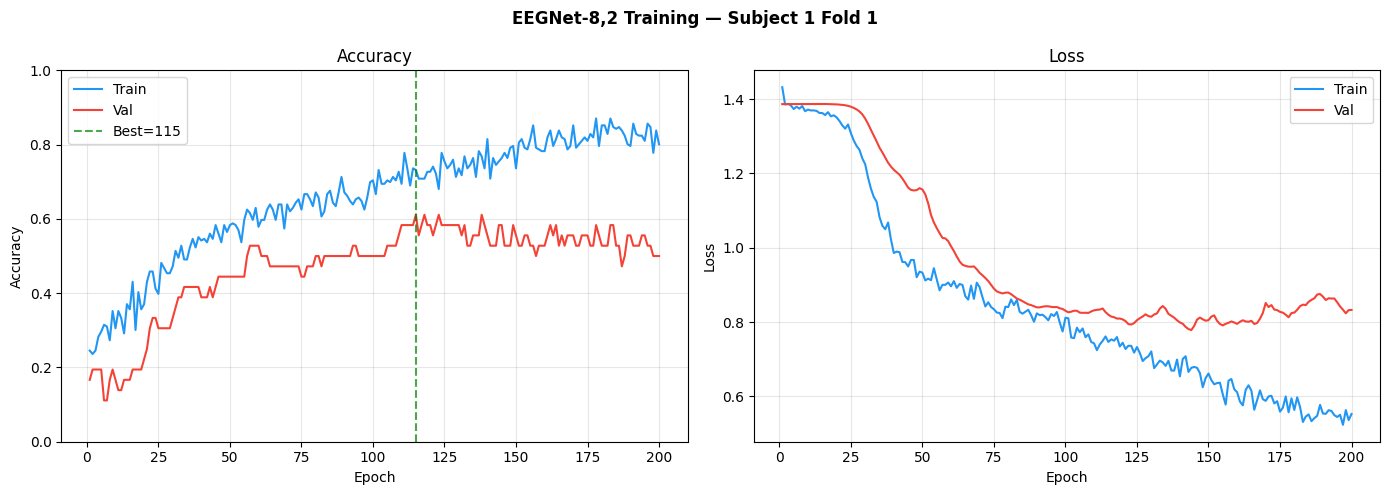

Best val accuracy : 61.11% at epoch 115
Final train acc   : 80.09%


In [22]:
#--------------------
# Trainig curves
#--------------------
def plot_training_curves(history, subject_id=0, fold_id=0):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'EEGNet-8,2 Training — Subject {subject_id+1} Fold {fold_id+1}',
        fontsize=12, fontweight='bold'
    )
    ep = range(1, len(history.history['loss']) + 1)

    ax1.plot(ep, history.history['accuracy'],
             label='Train', color='#2196F3', linewidth=1.5)
    ax1.plot(ep, history.history['val_accuracy'],
             label='Val',   color='#F44336', linewidth=1.5)
    best_ep = np.argmax(history.history['val_accuracy']) + 1
    ax1.axvline(best_ep, color='green',
                linestyle='--', alpha=0.7, label=f'Best={best_ep}')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    ax2.plot(ep, history.history['loss'],
             label='Train', color='#2196F3', linewidth=1.5)
    ax2.plot(ep, history.history['val_loss'],
             label='Val',   color='#F44336', linewidth=1.5)
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'training_curves_s{subject_id+1}_f{fold_id+1}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Best val accuracy : '
          f'{max(history.history["val_accuracy"]):.2%} '
          f'at epoch {best_ep}')
    print(f'Final train acc   : '
          f'{history.history["accuracy"][-1]:.2%}')


plot_training_curves(hist, subject_id=0, fold_id=0)

              RESULTS — Subject 1 Fold 1               
  Test Accuracy    : 61.11%
  F1 Macro         : 0.6012

  Per-Class F1:
    Left Hand   : 0.5000  ██████████
    Right Hand  : 0.6667  █████████████
    Feet        : 0.5714  ███████████
    Tongue      : 0.6667  █████████████

              precision    recall  f1-score   support

   Left Hand       0.67      0.40      0.50        10
  Right Hand       0.53      0.89      0.67         9
        Feet       0.67      0.50      0.57         8
      Tongue       0.67      0.67      0.67         9

    accuracy                           0.61        36
   macro avg       0.63      0.61      0.60        36
weighted avg       0.63      0.61      0.60        36



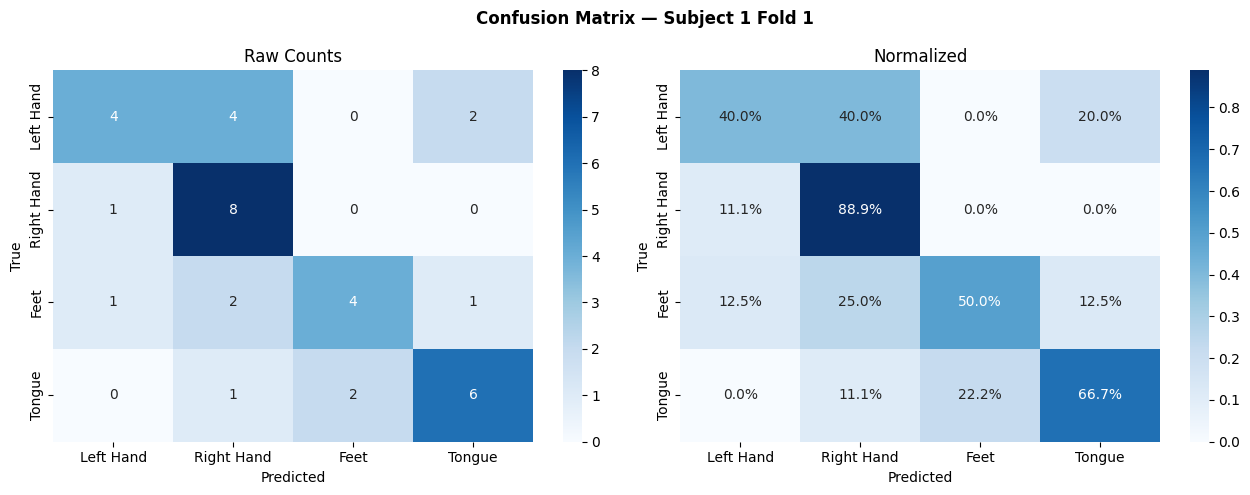

In [23]:
#--------------------
# F1 Score & Confusion Matrix
#--------------------
def evaluate_model(model, X_test, y_test_cat,
                   subject_id=0, fold_id=0):
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = np.argmax(y_test_cat,  axis=1)

    acc      = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_each  = f1_score(y_true, y_pred, average=None,
                         labels=range(N_CLASSES))

    print('=' * 55)
    print(f'{"RESULTS — Subject " + str(subject_id+1) + " Fold " + str(fold_id+1):^55}')
    print('=' * 55)
    print(f'  Test Accuracy    : {acc:.2%}')
    print(f'  F1 Macro         : {f1_macro:.4f}')
    print(f'\n  Per-Class F1:')
    for name, f1 in zip(CLASS_NAMES, f1_each):
        bar = '█' * int(f1 * 20)
        print(f'    {name:<12}: {f1:.4f}  {bar}')
    print(f'\n{classification_report(y_true, y_pred, target_names=CLASS_NAMES)}')

    # Confusion matrices
    cm   = confusion_matrix(y_true, y_pred)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        f'Confusion Matrix — Subject {subject_id+1} Fold {fold_id+1}',
        fontsize=12, fontweight='bold'
    )
    sns.heatmap(cm,   annot=True, fmt='d',    cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=ax1)
    ax1.set_title('Raw Counts')
    ax1.set_ylabel('True')
    ax1.set_xlabel('Predicted')

    sns.heatmap(cm_n, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=ax2)
    ax2.set_title('Normalized')
    ax2.set_ylabel('True')
    ax2.set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig(f'confusion_s{subject_id+1}_f{fold_id+1}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return acc, f1_macro


acc, f1 = evaluate_model(
    trained_model, X_test, y_test,
    subject_id=0, fold_id=0
)

In [ ]:
#--------------------
# Test on 20 Random Samples
#--------------------
def test_random_samples(model, X_test, y_test_cat,
                         subject_id=0, n=20):
    np.random.seed(42)
    idxs        = np.random.choice(len(X_test), n, replace=False)
    X_rand      = X_test[idxs]
    y_true_rand = np.argmax(y_test_cat[idxs], axis=1)

    probs  = model.predict(X_rand, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    # ── Text table ────────────────────────────────────────────
    print('=' * 68)
    print(f'{"20 RANDOM SAMPLE PREDICTIONS — Subject " + str(subject_id+1):^68}')
    print('=' * 68)
    print(f'{"#":>3} | {"True":^14} | {"Predicted":^14} | '
          f'{"Confidence":>10} | {"Result":>10}')
    print('-' * 68)
    correct = 0
    for i in range(n):
        tc   = CLASS_NAMES[y_true_rand[i]]
        pc   = CLASS_NAMES[y_pred[i]]
        conf = probs[i, y_pred[i]]
        ok   = y_true_rand[i] == y_pred[i]
        correct += int(ok)
        icon = 'OK' if ok else 'NO'
        print(f'{i+1:>3} | {tc:^14} | {pc:^14} | '
              f'{conf:>9.1%} | {icon} {("CORRECT" if ok else "WRONG"):>7}')
    print('=' * 68)
    print(f'Score: {correct}/{n} correct ({correct/n:.0%})')

    # ── Visual grid ───────────────────────────────────────────
    fig, axes = plt.subplots(4, 5, figsize=(18, 10))
    fig.suptitle(
        f'20 Random Predictions — Subject {subject_id+1}',
        fontsize=12, fontweight='bold'
    )
    time_ax = np.linspace(TMIN, TMAX,
                           X_rand.shape[3])

    for i, ax in enumerate(axes.flatten()):
        sig  = X_rand[i, 0, :, :].mean(axis=0) * 1e6
        tc   = y_true_rand[i]
        pc   = y_pred[i]
        ok   = tc == pc
        col  = '#4CAF50' if ok else '#F44336'

        ax.plot(time_ax, sig, color=col, linewidth=1.2)
        ax.set_title(
            f'T: {CLASS_NAMES[tc]}\n'
            f'P: {CLASS_NAMES[pc]} ({probs[i,pc]:.0%})',
            fontsize=7, color=col
        )
        ax.set_xlabel('s', fontsize=6)
        ax.set_ylabel('µV', fontsize=6)
        ax.tick_params(labelsize=5)
        ax.grid(True, alpha=0.3)
        for spine in ax.spines.values():
            spine.set_edgecolor(col)
            spine.set_linewidth(2.5)

    plt.tight_layout()
    plt.savefig(f'random20_s{subject_id+1}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


test_random_samples(trained_model, X_test, y_test, subject_id=0)

              20 RANDOM SAMPLE PREDICTIONS — Subject 1              
  # |      True      |   Predicted    | Confidence |     Result
--------------------------------------------------------------------
  1 |      Feet      |      Feet      |     52.9% | OK CORRECT
  2 |     Tongue     |   Right Hand   |     41.7% | NO   WRONG
  3 |     Tongue     |     Tongue     |     63.1% | OK CORRECT
  4 |   Right Hand   |   Right Hand   |     56.9% | OK CORRECT
  5 |   Left Hand    |   Right Hand   |     50.8% | NO   WRONG
  6 |   Left Hand    |   Right Hand   |     58.6% | NO   WRONG
  7 |     Tongue     |      Feet      |     65.0% | NO   WRONG
  8 |   Left Hand    |   Left Hand    |     41.7% | OK CORRECT
  9 |   Right Hand   |   Right Hand   |     52.1% | OK CORRECT
 10 |   Left Hand    |   Right Hand   |     40.3% | NO   WRONG
 11 |      Feet      |      Feet      |     42.4% | OK CORRECT
 12 |      Feet      |   Right Hand   |     41.1% | NO   WRONG
 13 |     Tongue     |     Tongue     |   